In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import seaborn as sns


Quartiles and IQR for Power:
Q1_power: 1803.5
Q3_power: 3625.0
IQR_power: 1821.5

Quartiles and IQR for RPM:
Q1_rpm: 75.455
Q3_rpm: 130.0
IQR_rpm: 54.545

Predicted RPM: [[ 73.75138504]
 [ 74.70340194]
 [ 75.65902141]
 [ 76.61794464]
 [ 77.57987282]
 [ 78.54450718]
 [ 79.5115489 ]
 [ 80.4806992 ]
 [ 81.45165926]
 [ 82.42413031]
 [ 83.39781354]
 [ 84.37241015]
 [ 85.34762134]
 [ 86.32314832]
 [ 87.2986923 ]
 [ 88.27395447]
 [ 89.24863604]
 [ 90.22243821]
 [ 91.19506218]
 [ 92.16620916]
 [ 93.13558035]
 [ 94.10287695]
 [ 95.06780016]
 [ 96.03005119]
 [ 96.98933125]
 [ 97.94534152]
 [ 98.89778323]
 [ 99.84635756]
 [100.79076573]
 [101.73070893]
 [102.66588837]
 [103.59600525]
 [104.52076077]
 [105.43985614]
 [106.35299256]
 [107.25987123]
 [108.16019336]
 [109.05366015]
 [109.9399728 ]
 [110.81883251]
 [111.68994049]
 [112.55299794]
 [113.40770606]
 [114.25376606]
 [115.09087914]
 [115.9187465 ]
 [116.73706934]
 [117.54554887]
 [118.34388629]
 [119.13178281]
 [119.90893962]
 [120.6750579

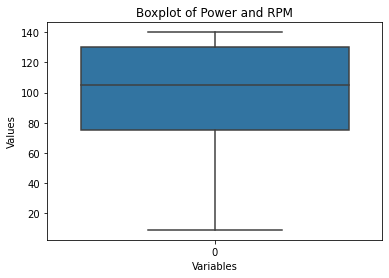

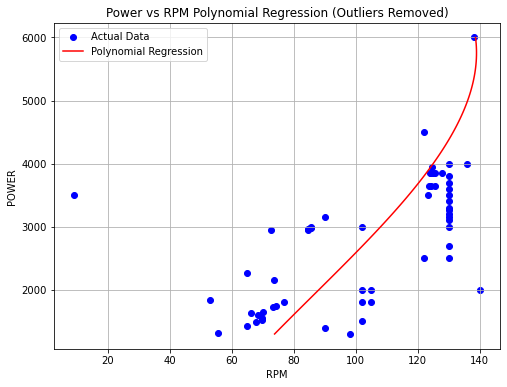

In [9]:
power_rpm = [  
    [9, 3500],
    [52.75, 1841],
    [55.6, 1309],
    [64.84, 2264],
    [65, 1423],
    [66.01, 1640],
    [67.8, 1483],
    [68.25, 1608],
    [69.79, 1558],
    [69.8, 1529],
    [69.99, 1648],
    [72.55, 2952],
    [73.24, 1726],
    [73.52, 2155],
    [74.22, 1748],
    [76.69, 1807],
    [84.49, 2952],
    [84.67, 2959],
    [85.29, 2982],
    [85.4, 2985],
    [85.64, 2998],
    [90, 1400],
    [90.17, 3151],
    [98, 1300],
    [102, 1500],
    [102, 3000],
    [102, 2000],
    [102, 1800],
    [105, 2000],
    [105, 1800],
    [122, 4500],
    [122, 2500],
    [123.3, 3500],
    [123.6, 3650],
    [123.8, 3850],
    [124.3, 3850],
    [124.4, 3650],
    [124.7, 3950],
    [124.9, 3850],
    [125.4, 3650],
    [125.4, 3850],
    [127.9, 3850],
    [130, 3800],
    [130, 3700],
    [130, 3300],
    [130, 3100],
    [130, 3200],
    [130, 2700],
    [130, 3400],
    [130, 3500],
    [130, 2500],
    [130, 3600],
    [130, 3000],
    [130, 3260],
    [130, 3150],
    [130, 4000],
    [136, 4000],
    [138, 6000],
    [140, 2000]
]


rpm_list = [item[0] for item in power_rpm]
power_list = [item[1] for item in power_rpm]

# Calculate Quartiles and IQR for power and rpm
Q1_power, Q3_power = np.percentile(power_list, [25, 75])
IQR_power = Q3_power - Q1_power

Q1_rpm, Q3_rpm = np.percentile(rpm_list, [25, 75])
IQR_rpm = Q3_rpm - Q1_rpm

# Combine power and rpm lists for Boxplot visualization
#combined_data = np.array([power_list, rpm_list]).T
a=rpm_list
# Create a boxplot to visualize the data
plt.figure(figsize=(6, 4))
sns.boxplot(data=a)
plt.xlabel('Variables')
plt.ylabel('Values')
plt.title('Boxplot of Power and RPM')

# Define outlier boundaries for power and rpm
lower_bound_power = Q1_power - 1.5 * IQR_power
upper_bound_power = Q3_power + 1.5 * IQR_power

lower_bound_rpm = Q1_rpm - 1.5 * IQR_rpm
upper_bound_rpm = Q3_rpm + 1.5 * IQR_rpm

# Print calculated Quartiles and IQR for power and rpm
print("\nQuartiles and IQR for Power:")
print("Q1_power:", Q1_power)
print("Q3_power:", Q3_power)
print("IQR_power:", IQR_power)

print("\nQuartiles and IQR for RPM:")
print("Q1_rpm:", Q1_rpm)
print("Q3_rpm:", Q3_rpm)
print("IQR_rpm:", IQR_rpm)


# Filter data to exclude outliers
filtered_power_rpm = [(power_list[i], rpm_list[i]) for i in range(len(power_list))
                      if (lower_bound_power <= power_list[i] <= upper_bound_power)
                      and (lower_bound_rpm <= rpm_list[i] <= upper_bound_rpm)]

# Separate power and rpm lists again after outlier removal
filtered_power_list = [item[0] for item in filtered_power_rpm]
filtered_rpm_list = [item[1] for item in filtered_power_rpm]


# Polynomial regression on filtered data
power = np.array(filtered_power_list).reshape(-1, 1)
rpm = np.array(filtered_rpm_list).reshape(-1, 1)

poly_features = PolynomialFeatures(degree=3)
power_poly = poly_features.fit_transform(power)

# Applying polynomial regression to filtered data
model = LinearRegression()
model.fit(power_poly, rpm)

# Generating a sequence of power values for visualization
power_seq = np.linspace(min(filtered_power_list), max(filtered_power_list), 100).reshape(-1, 1)
predicted_rpm = model.predict(poly_features.transform(power_seq))

print('\nPredicted RPM:', predicted_rpm)

# Visualizing the regression results
plt.figure(figsize=(8, 6))
plt.scatter( filtered_rpm_list,filtered_power_list, label='Actual Data', color='blue')
plt.plot( predicted_rpm, power_seq, color='red', label='Polynomial Regression')

plt.title('Power vs RPM Polynomial Regression (Outliers Removed)')
plt.xlabel('RPM')
plt.ylabel('POWER')
plt.legend()
plt.grid(True)
plt.show()

Predicted RPM: [[ 78.46292715]
 [ 78.47062961]
 [ 78.5260403 ]
 [ 78.6280683 ]
 [ 78.77562268]
 [ 78.96761252]
 [ 79.20294689]
 [ 79.48053488]
 [ 79.79928555]
 [ 80.15810799]
 [ 80.55591127]
 [ 80.99160446]
 [ 81.46409665]
 [ 81.9722969 ]
 [ 82.5151143 ]
 [ 83.09145792]
 [ 83.70023684]
 [ 84.34036014]
 [ 85.01073688]
 [ 85.71027615]
 [ 86.43788703]
 [ 87.19247858]
 [ 87.97295989]
 [ 88.77824003]
 [ 89.60722807]
 [ 90.45883311]
 [ 91.3319642 ]
 [ 92.22553043]
 [ 93.13844087]
 [ 94.0696046 ]
 [ 95.01793069]
 [ 95.98232823]
 [ 96.96170629]
 [ 97.95497394]
 [ 98.96104026]
 [ 99.97881432]
 [101.00720522]
 [102.045122  ]
 [103.09147377]
 [104.14516959]
 [105.20511853]
 [106.27022968]
 [107.33941211]
 [108.4115749 ]
 [109.48562711]
 [110.56047784]
 [111.63503616]
 [112.70821113]
 [113.77891185]
 [114.84604738]
 [115.9085268 ]
 [116.96525918]
 [118.01515361]
 [119.05711916]
 [120.0900649 ]
 [121.11289992]
 [122.12453329]
 [123.12387407]
 [124.10983136]
 [125.08131423]
 [126.03723175]
 [126.976

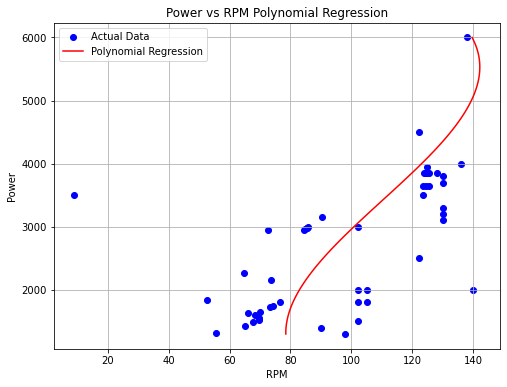

In [3]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

power_rpm = [
    [9, 3500],
    [52.75, 1841],
    [55.6, 1309],
    [64.84, 2264],
    [65, 1423],
    [66.01, 1640],
    [67.8, 1483],
    [68.25, 1608],
    [69.79, 1558],
    [69.8, 1529],
    [69.99, 1648],
    [72.55, 2952],
    [73.24, 1726],
    [73.52, 2155],
    [74.22, 1748],
    [76.69, 1807],
    [84.49, 2952],
    [84.67, 2959],
    [85.29, 2982],
    [85.4, 2985],
    [85.64, 2998],
    [90, 1400],
    [90.17, 3151],
    [98, 1300],
    [102, 1500],
    [102, 3000],
    [102, 2000],
    [102, 1800],
    [105, 2000],
    [105, 1800],
    [122, 4500],
    [122, 2500],
    [123.3, 3500],
    [123.6, 3650],
    [123.8, 3850],
    [124.3, 3850],
    [124.4, 3650],
    [124.7, 3950],
    [124.9, 3850],
    [125.4, 3650],
    [125.4, 3850],
    [127.9, 3850],
    [130, 3800],
    [130, 3700],
    [130, 3300],
    [130, 3100],
    [130, 3200],
    #[130, 2700],
    #[130, 3400],
    #[130, 3500],
    #[130, 2500],
    #[130, 3600],
    #[130, 3000],
    #[130, 3260],
    #[130, 3150],
    #[130, 4000],
    [136, 4000],
    [138, 6000],
    [140, 2000],
   
]

rpm_list = [item[0] for item in power_rpm]
power_list = [item[1] for item in power_rpm]

power = np.array(power_list).reshape(-1, 1)
rpm = np.array(rpm_list).reshape(-1, 1)

poly_features = PolynomialFeatures(degree=3) 
power_poly = poly_features.fit_transform(power)

# Applying polynomial regression
model = LinearRegression()
model.fit(power_poly, rpm)

# Generating a sequence of power values for visualization
power_seq = np.linspace(min(power_list), max(power_list), 100).reshape(-1, 1)
predicted_rpm = model.predict(poly_features.transform(power_seq))

print('Predicted RPM:', predicted_rpm)

plt.figure(figsize=(8, 6))
plt.scatter(rpm_list, power_list, label='Actual Data', color='blue')
plt.plot(predicted_rpm,power_seq, color='red', label='Polynomial Regression')

plt.title('Power vs RPM Polynomial Regression')
plt.xlabel('RPM')
plt.ylabel('Power')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
power_rpm = [
    
    [9, 3500],
    [52.75, 1841],
    [55.6, 1309],
    [64.84, 2264],
    [65, 1423],
    [66.01, 1640],
    [67.8, 1483],
    [68.25, 1608],
    [69.79, 1558],
    [69.8, 1529],
    [69.99, 1648],
    [72.55, 2952],
    [73.24, 1726],
    [73.52, 2155],
    [74.22, 1748],
    [76.69, 1807],
    [84.49, 2952],
    [84.67, 2959],
    [85.29, 2982],
    [85.4, 2985],
    [85.64, 2998],
    [90, 1400],
    [90.17, 3151],
    [98, 1300],
    [102, 1500],
    [102, 3000],
    [102, 2000],
    [102, 1800],
    [105, 2000],
    [105, 1800],
    [122, 4500],
    [122, 2500],
    [123.3, 3500],
    [123.6, 3650],
    [123.8, 3850],
    [124.3, 3850],
    [124.4, 3650],
    [124.7, 3950],
    [124.9, 3850],
    [125.4, 3650],
    [125.4, 3850],
    [127.9, 3850],
    #[130, 3800],
    #[130, 3700],
    [130, 3300],
    [130, 3100],
    [130, 3200],
    [130, 2700],
    [130, 3400],
    #[130, 3500],
    [130, 2500],
    #[130, 3600],
    [130, 3000],
    [130, 3260],
    [130, 3150],
    [130, 4000],
    [136, 4000],
    [138, 6000],
    [140, 2000],
    [428, 4378.5],
   
]

rpm_list = [item[0] for item in power_rpm]
power_list = [item[1] for item in power_rpm]

# Calculate Quartiles and IQR for power and rpm
Q1_power, Q3_power = np.percentile(power_list, [25, 75])
IQR_power = Q3_power - Q1_power

Q1_rpm, Q3_rpm = np.percentile(rpm_list, [25, 75])
IQR_rpm = Q3_rpm - Q1_rpm

# Define outlier boundaries for power and rpm
lower_bound_power = Q1_power - 1.5 * IQR_power
upper_bound_power = Q3_power + 1.5 * IQR_power

lower_bound_rpm = Q1_rpm - 1.5 * IQR_rpm
upper_bound_rpm = Q3_rpm + 1.5 * IQR_rpm

# Print calculated Quartiles and IQR for power and rpm
print("\nQuartiles and IQR for Power:")
print("Q1_power:", Q1_power)
print("Q3_power:", Q3_power)
print("IQR_power:", IQR_power)

print("\nQuartiles and IQR for RPM:")
print("Q1_rpm:", Q1_rpm)
print("Q3_rpm:", Q3_rpm)
print("IQR_rpm:", IQR_rpm)


# Filter data to exclude outliers
filtered_power_rpm = [(power_list[i], rpm_list[i]) for i in range(len(power_list))
                      if (lower_bound_power <= power_list[i] <= upper_bound_power)
                      and (lower_bound_rpm <= rpm_list[i] <= upper_bound_rpm)]

# Separate power and rpm lists again after outlier removal
filtered_power_list = [item[0] for item in filtered_power_rpm]
filtered_rpm_list = [item[1] for item in filtered_power_rpm]

# Polynomial regression on filtered data
power = np.array(filtered_power_list).reshape(-1, 1)
rpm = np.array(filtered_rpm_list).reshape(-1, 1)

poly_features = PolynomialFeatures(degree=3)
power_poly = poly_features.fit_transform(power)

# Applying polynomial regression to filtered data
model = LinearRegression()
model.fit(power_poly, rpm)

# Generating a sequence of power values for visualization
power_seq = np.linspace(min(filtered_power_list), max(filtered_power_list), 100).reshape(-1, 1)
predicted_rpm = model.predict(poly_features.transform(power_seq))

print('\nPredicted RPM:', predicted_rpm)

# Visualizing the regression results
plt.figure(figsize=(8, 6))
plt.scatter( filtered_rpm_list,filtered_power_list, label='Actual Data', color='blue')
plt.plot( predicted_rpm, power_seq, color='red', label='Polynomial Regression')

plt.title('Power vs RPM Polynomial Regression (Outliers Removed)')
plt.xlabel('RPM')
plt.ylabel('POWER')
plt.legend()
plt.grid(True)
plt.show()

# Aditi

In [1]:
import pandas as pd

rpm_values = [
    0, 0, 27.1, 27.8, 28, 30, 30, 30.1, 31.5, 32.3, 32.4, 33, 33.2, 33.3, 33.9, 34.2, 34.6, 35.4, 36.4, 37.7, 38.3, 38.3,
    39.2, 39.6, 39.7, 40.5, 40.7, 40.9, 41, 41.2, 41.7, 41.8, 42, 42.1, 42.1, 42.1, 42.1, 42.1, 42.3, 42.4, 
    42.5, 42.8, 43, 43.1, 43.6, 44.1, 44.2, 44.3, 44.5, 44.5, 44.5, 44.8, 44.8, 45.1, 45.2, 45.2, 45.2, 45.4, 45.6,
    45.6, 45.9, 45.9, 45.9, 46.07, 46.2, 46.2, 46.3, 46.4, 46.5, 46.7, 47, 47.1, 47.3, 47.4, 47.7, 48.4, 48.8, 50,
    50.1, 50.6, 50.7, 50.9, 50.9, 50.9, 51, 51.1, 51.3, 51.5, 51.6, 51.8, 52, 52.1, 52.2, 52.3, 52.3, 52.3, 52.3, 52.3,
    53, 53.2, 53.3, 53.4, 53.4, 53.5, 53.6, 53.8, 54, 54, 54.2, 54.4, 54.5, 54.6, 54.7, 54.8, 55, 55, 55.1, 55.3,
    55.5, 55.8, 55.9, 56.3, 56.4, 56.7, 57.1, 57.2, 57.3, 57.3, 57.6, 57.6, 57.7, 57.7, 57.8, 57.8, 58.3, 58.4, 58.6,
    58.7, 58.8, 58.9, 59, 59.2, 59.7, 59.7, 59.8, 60, 60.1, 60.2, 60.3, 60.3, 60.4, 60.4, 60.4, 60.4, 60.4, 61.4, 61.5,
    61.6, 61.7, 61.7, 62.1, 62.1, 62.1, 62.3, 62.6, 62.7, 62.7, 63, 63.3, 63.5, 64, 64.1, 64.7, 64.7, 65, 65, 65,
    65.2, 65.3, 65.4, 65.8, 65.8, 66, 66.1, 67, 67.1, 67.1, 67.4, 67.4, 67.4, 67.7, 67.9, 67.9, 68, 68.3, 68.5, 68.5,
    68.6, 68.7, 68.9, 69.2, 69.4, 69.4, 69.8, 69.9, 69.9, 70, 70, 70.1, 70.2, 70.7, 71, 71.1, 71.1, 71.2, 71.5, 72.1, 72.6,
    72.9, 73, 74.1, 74.1, 74.2, 74.3, 74.3, 75, 75.1, 75.3, 75.3, 75.4, 75.6, 75.8, 75.9, 76.2, 76.5, 77.1, 77.2, 77.4,
    77.7, 77.8, 77.8, 77.9, 78, 78, 78.1, 78.2, 78.4, 78.6, 80.2, 80.2, 80.3, 81.7, 82.1, 82.1, 82.4, 85.2, 85.2
]

power_values = [
    2600, 5409, 1061, 2339, 896, 1350, 3000, 2444, 850, 0, 1755, 1904, 618, 1504, 1755, 0, 1942, 1438, 0, 3358,
    2780, 2910, 984, 1504, 2240, 1666.7, 1773, 1930, 1600, 2410, 2780, 2170, 2766, 1777, 1145, 3425, 3121, 1757.9, 1662.5,
    1691.7, 1813, 1929.2, 1747.8, 2420, 3120, 2009.3, 3130, 2306.9, 2024, 2780, 2870, 2604, 2256, 2890, 2279,
    1841.7, 2470, 2125, 2185.2, 3050, 2720, 2312.5, 3370, 2600, 7629, 3616, 2400, 4780, 2363, 2548, 2133.3, 2533.3, 2325,
    3419, 0, 2891, 2575, 2712, 3170, 3100, 2962, 3394, 3072, 5498, 2700, 3280, 3370, 3311, 3120, 3400, 3300, 5623, 2500,
    5200, 4570, 4274, 3630, 9400, 3640, 3000, 3200, 3905, 3704, 3570, 3743, 5000, 4671, 4971, 3860, 5000, 3176, 4314, 3966,
    3985, 4035, 1693, 2300, 9861.1, 4120, 4067, 5026, 2000, 2519, 4750, 4480, 4500, 8928, 4512, 4400, 4604, 4610, 4530, 4750,
    2620, 4809, 4770, 5034, 4840, 4930, 5321, 4900, 4765, 5764, 4870, 4819, 5609, 6330, 4779, 4210, 4966, 5220, 4800, 5170,
    4992, 5240, 5475, 5642, 5320, 5600, 5800, 5392, 6263, 6950, 3740, 5315, 10600, 5278, 5895, 4870, 6420, 5654, 6196, 6350,
     6542, 5625, 7857, 7530, 5987, 5490, 0, 6429, 6657, 7968, 6766, 7075, 5924, 8200, 7957, 6788, 7110, 7592, 7280,
    8576, 6048, 7000, 7679, 7450, 7230, 7655, 7229, 6733, 6760, 7198, 7860, 7879, 7890, 4667, 8450, 7394.1, 7321, 6700, 8200,
    7848, 8250, 8883, 8970, 8600, 9111.1, 8420, 8910, 9295, 8821, 8500, 9350, 10446, 8600, 11248, 7730, 10660, 9591, 11058,
    11060, 10400, 10050, 10130, 9570, 10390, 10400, 10400, 9900, 10141.7, 10900, 10800, 10600, 10760, 10770, 10169.6, 10928,
    11466, 11350, 11620, 10354, 10556, 11404, 13823, 12600, 13356
]



df = pd.DataFrame({'RPM': rpm_values, 'Power': power_values})

print(df)



      RPM    Power
0     0.0   2600.0
1     0.0   5409.0
2    27.1   1061.0
3    27.8   2339.0
4    28.0    896.0
..    ...      ...
252  82.1  10556.0
253  82.1  11404.0
254  82.4  13823.0
255  85.2  12600.0
256  85.2  13356.0

[257 rows x 2 columns]


Before Outlier

Predicted RPM: [45.82697905 58.7792161  38.66012763 44.60162087 37.90544611 39.99050759
 47.70606079 45.09439098 37.6957458  33.88605083 41.87001371 42.56501703
 36.64312517 40.70332767 41.87001371 33.88605083 42.7425149  40.39753026
 33.88605083 49.3853767  46.67262465 47.28335645 38.30746913 40.70332767
 44.13733887 41.45895173 41.95388608 42.68645274 41.14888447 44.93479329
 46.67262465 43.80929442 46.60684852 41.97252781 39.04574743 49.69909528
 48.27410716 41.88352477 41.43941576 41.57526843 42.14035825 42.68271559
 41.83647189 44.98173066 48.2694141  43.05709736 48.31634343 44.45104201
 43.12584629 46.67262465 47.09545283 45.84576856 44.21234938 47.18940676
 44.32019456 42.27422552 45.21645558 43.59852637 43.88050865 47.94083284
 46.39072701 44.47730867 49.44158144 45.82697905 67.93515786 50.59204796
 44.88785864 55.96032091 44.71422543 45.58273511 43.63739401 45.51369676
 44.53594354 49.67101038 33.88605083 47.19410435 45.70954926 46.35314105
 48.50403047 48.17554691 47.52760133

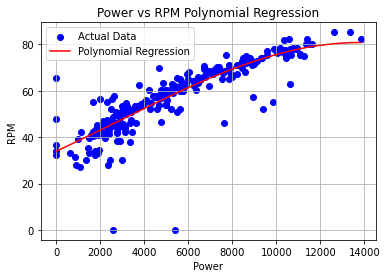

In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt 
import numpy as np

X = df[['Power']]
y = df['RPM']

# Define polynomial degree
degree = 3

# Polynomial transformation
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)

# Fit the model
model = LinearRegression()
model.fit(X_poly, y)

# Predict using the model
y_pred = model.predict(X_poly)

#print('Coefficients:', model.coef_)

#print('Intercept:', model.intercept_)

# Print the predicted values
print('Predicted RPM:', y_pred)

plt.scatter(df['Power'], df['RPM'], label='Actual Data', color='blue')

# Sort the values for better visualization
sort_axis = np.argsort(X.values.flatten())
plt.plot(X.values[sort_axis], y_pred[sort_axis], color='red', label='Polynomial Regression')

plt.title('Power vs RPM Polynomial Regression')
plt.xlabel('Power')
plt.ylabel('RPM')
plt.legend()
plt.grid(True)
plt.show()

After removal of outlier 

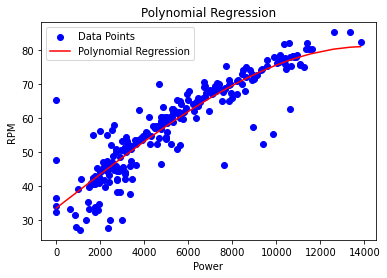

Coefficients: [ 0.00000000e+00  4.99440607e-03  1.00430223e-08 -8.89738427e-12]
Intercept: 33.505400462364946
Predicted RPM: [38.805144   45.12840561 37.98205091 40.24426116 48.3387765  45.64183016
 37.7524376  33.50540046 42.25342156 42.98974434 36.59367904 41.00943513
 42.25342156 33.50540046 43.1772486  40.68166689 33.50540046 50.05296017
 47.27630596 47.90491658 38.42114315 41.00943513 44.64326045 41.81628139
 42.34246359 43.11804963 41.48571663 45.47570865 47.27630596 44.29963697
 47.208478   42.36224744 39.22380599 50.3715785  48.92028199 42.26776884
 41.7954751  41.94010312 42.54024781 43.11410261 42.21779806 45.52458104
 48.91548482 43.50903049 48.96344991 44.97121097 43.58144796 47.27630596
 47.71173595 46.42183046 44.72173518 47.80835311 44.83449752 42.68208258
 45.76877826 44.07848723 44.37429286 48.57932205 46.98543944 44.99864203
 50.11007913 46.40236665 68.24162535 51.27581403 45.4268254  56.63639752
 45.24586387 46.14916548 44.11929143 46.07753029 45.05986037 50.34307506

In [3]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

import pandas as pd

rpm_values = [
    0, 0, 27.1, 27.8, 28, 30, 30, 30.1, 31.5, 32.3, 32.4, 33, 33.2, 33.3, 33.9, 34.2, 34.6, 35.4, 36.4, 37.7, 38.3, 38.3,
    39.2, 39.6, 39.7, 40.5, 40.7, 40.9, 41, 41.2, 41.7, 41.8, 42, 42.1, 42.1, 42.1, 42.1, 42.1, 42.3, 42.4, 
    42.5, 42.8, 43, 43.1, 43.6, 44.1, 44.2, 44.3, 44.5, 44.5, 44.5, 44.8, 44.8, 45.1, 45.2, 45.2, 45.2, 45.4, 45.6,
    45.6, 45.9, 45.9, 45.9, 46.07, 46.2, 46.2, 46.3, 46.4, 46.5, 46.7, 47, 47.1, 47.3, 47.4, 47.7, 48.4, 48.8, 50,
    50.1, 50.6, 50.7, 50.9, 50.9, 50.9, 51, 51.1, 51.3, 51.5, 51.6, 51.8, 52, 52.1, 52.2, 52.3, 52.3, 52.3, 52.3, 52.3,
    53, 53.2, 53.3, 53.4, 53.4, 53.5, 53.6, 53.8, 54, 54, 54.2, 54.4, 54.5, 54.6, 54.7, 54.8, 55, 55, 55.1, 55.3,
    55.5, 55.8, 55.9, 56.3, 56.4, 56.7, 57.1, 57.2, 57.3, 57.3, 57.6, 57.6, 57.7, 57.7, 57.8, 57.8, 58.3, 58.4, 58.6,
    58.7, 58.8, 58.9, 59, 59.2, 59.7, 59.7, 59.8, 60, 60.1, 60.2, 60.3, 60.3, 60.4, 60.4, 60.4, 60.4, 60.4, 61.4, 61.5,
    61.6, 61.7, 61.7, 62.1, 62.1, 62.1, 62.3, 62.6, 62.7, 62.7, 63, 63.3, 63.5, 64, 64.1, 64.7, 64.7, 65, 65, 65,
    65.2, 65.3, 65.4, 65.8, 65.8, 66, 66.1, 67, 67.1, 67.1, 67.4, 67.4, 67.4, 67.7, 67.9, 67.9, 68, 68.3, 68.5, 68.5,
    68.6, 68.7, 68.9, 69.2, 69.4, 69.4, 69.8, 69.9, 69.9, 70, 70, 70.1, 70.2, 70.7, 71, 71.1, 71.1, 71.2, 71.5, 72.1, 72.6,
    72.9, 73, 74.1, 74.1, 74.2, 74.3, 74.3, 75, 75.1, 75.3, 75.3, 75.4, 75.6, 75.8, 75.9, 76.2, 76.5, 77.1, 77.2, 77.4,
    77.7, 77.8, 77.8, 77.9, 78, 78, 78.1, 78.2, 78.4, 78.6, 80.2, 80.2, 80.3, 81.7, 82.1, 82.1, 82.4, 85.2, 85.2
]

power_values = [
    2600, 5409, 1061, 2339, 896, 1350, 3000, 2444, 850, 0, 1755, 1904, 618, 1504, 1755, 0, 1942, 1438, 0, 3358,
    2780, 2910, 984, 1504, 2240, 1666.7, 1773, 1930, 1600, 2410, 2780, 2170, 2766, 1777, 1145, 3425, 3121, 1757.9, 1662.5,
    1691.7, 1813, 1929.2, 1747.8, 2420, 3120, 2009.3, 3130, 2306.9, 2024, 2780, 2870, 2604, 2256, 2890, 2279,
    1841.7, 2470, 2125, 2185.2, 3050, 2720, 2312.5, 3370, 2600, 7629, 3616, 2400, 4780, 2363, 2548, 2133.3, 2533.3, 2325,
    3419, 0, 2891, 2575, 2712, 3170, 3100, 2962, 3394, 3072, 5498, 2700, 3280, 3370, 3311, 3120, 3400, 3300, 5623, 2500,
    5200, 4570, 4274, 3630, 9400, 3640, 3000, 3200, 3905, 3704, 3570, 3743, 5000, 4671, 4971, 3860, 5000, 3176, 4314, 3966,
    3985, 4035, 1693, 2300, 9861.1, 4120, 4067, 5026, 2000, 2519, 4750, 4480, 4500, 8928, 4512, 4400, 4604, 4610, 4530, 4750,
    2620, 4809, 4770, 5034, 4840, 4930, 5321, 4900, 4765, 5764, 4870, 4819, 5609, 6330, 4779, 4210, 4966, 5220, 4800, 5170,
    4992, 5240, 5475, 5642, 5320, 5600, 5800, 5392, 6263, 6950, 3740, 5315, 10600, 5278, 5895, 4870, 6420, 5654, 6196, 6350,
     6542, 5625, 7857, 7530, 5987, 5490, 0, 6429, 6657, 7968, 6766, 7075, 5924, 8200, 7957, 6788, 7110, 7592, 7280,
    8576, 6048, 7000, 7679, 7450, 7230, 7655, 7229, 6733, 6760, 7198, 7860, 7879, 7890, 4667, 8450, 7394.1, 7321, 6700, 8200,
    7848, 8250, 8883, 8970, 8600, 9111.1, 8420, 8910, 9295, 8821, 8500, 9350, 10446, 8600, 11248, 7730, 10660, 9591, 11058,
    11060, 10400, 10050, 10130, 9570, 10390, 10400, 10400, 9900, 10141.7, 10900, 10800, 10600, 10760, 10770, 10169.6, 10928,
    11466, 11350, 11620, 10354, 10556, 11404, 13823, 12600, 13356
]



df = pd.DataFrame({'RPM': rpm_values, 'Power': power_values})

print(df)


Q1_rpm = df['RPM'].quantile(0.25)
Q3_rpm = df['RPM'].quantile(0.75)
IQR_rpm = Q3_rpm - Q1_rpm

# Define the boundaries for outlier removal
lower_bound = Q1_rpm - 1.5 * IQR_rpm
upper_bound = Q3_rpm + 1.5 * IQR_rpm

# Remove outliers based on the calculated boundaries
filtered_df = df[(df['RPM'] >= lower_bound) & (df['RPM'] <= upper_bound)]

# Perform polynomial regression on the filtered data
X = filtered_df[['Power']]
y = filtered_df['RPM']

# Define polynomial degree
degree = 3

# Polynomial transformation
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)

# Fit the model
model = LinearRegression()
model.fit(X_poly, y)

# Predict using the model
y_pred = model.predict(X_poly)

# Plotting the data and regression line
plt.scatter(filtered_df['Power'], filtered_df['RPM'], color='blue', label='Data Points')
plt.plot(sorted(filtered_df['Power']), sorted(y_pred), color='red', label='Polynomial Regression')
plt.xlabel('Power')
plt.ylabel('RPM')
plt.title('Polynomial Regression')
plt.legend()
plt.show()

#print('Coefficients:', model.coef_)
#print('Intercept:', model.intercept_)
print('Predicted RPM:', y_pred)


R2 Score after outlier removal: 0.7809413354855903
Predicted RPM for new 'Power' values:
Power: 4809 -> Predicted RPM: 57.14468028254144
Power: 5609 -> Predicted RPM: 60.57895618460034
Power: 6350 -> Predicted RPM: 63.541077027965756


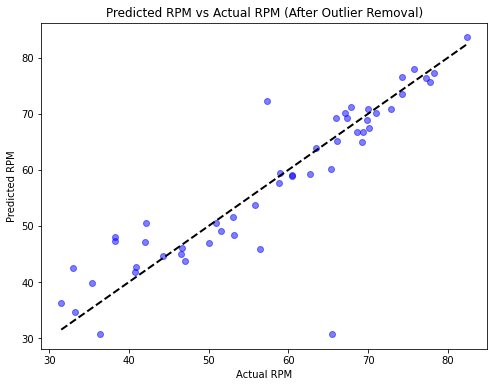

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

rpm_values = [
    0, 0, 27.1, 27.8, 28, 30, 30, 30.1, 31.5, 32.3, 32.4, 33, 33.2, 33.3, 33.9, 34.2, 34.6, 35.4, 36.4, 37.7, 38.3, 38.3,
    39.2, 39.6, 39.7, 40.5, 40.7, 40.9, 41, 41.2, 41.7, 41.8, 42, 42.1, 42.1, 42.1, 42.1, 42.1, 42.3, 42.4, 
    42.5, 42.8, 43, 43.1, 43.6, 44.1, 44.2, 44.3, 44.5, 44.5, 44.5, 44.8, 44.8, 45.1, 45.2, 45.2, 45.2, 45.4, 45.6,
    45.6, 45.9, 45.9, 45.9, 46.07, 46.2, 46.2, 46.3, 46.4, 46.5, 46.7, 47, 47.1, 47.3, 47.4, 47.7, 48.4, 48.8, 50,
    50.1, 50.6, 50.7, 50.9, 50.9, 50.9, 51, 51.1, 51.3, 51.5, 51.6, 51.8, 52, 52.1, 52.2, 52.3, 52.3, 52.3, 52.3, 52.3,
    53, 53.2, 53.3, 53.4, 53.4, 53.5, 53.6, 53.8, 54, 54, 54.2, 54.4, 54.5, 54.6, 54.7, 54.8, 55, 55, 55.1, 55.3,
    55.5, 55.8, 55.9, 56.3, 56.4, 56.7, 57.1, 57.2, 57.3, 57.3, 57.6, 57.6, 57.7, 57.7, 57.8, 57.8, 58.3, 58.4, 58.6,
    58.7, 58.8, 58.9, 59, 59.2, 59.7, 59.7, 59.8, 60, 60.1, 60.2, 60.3, 60.3, 60.4, 60.4, 60.4, 60.4, 60.4, 61.4, 61.5,
    61.6, 61.7, 61.7, 62.1, 62.1, 62.1, 62.3, 62.6, 62.7, 62.7, 63, 63.3, 63.5, 64, 64.1, 64.7, 64.7, 65, 65, 65,
    65.2, 65.3, 65.4, 65.8, 65.8, 66, 66.1, 67, 67.1, 67.1, 67.4, 67.4, 67.4, 67.7, 67.9, 67.9, 68, 68.3, 68.5, 68.5,
    68.6, 68.7, 68.9, 69.2, 69.4, 69.4, 69.8, 69.9, 69.9, 70, 70, 70.1, 70.2, 70.7, 71, 71.1, 71.1, 71.2, 71.5, 72.1, 72.6,
    72.9, 73, 74.1, 74.1, 74.2, 74.3, 74.3, 75, 75.1, 75.3, 75.3, 75.4, 75.6, 75.8, 75.9, 76.2, 76.5, 77.1, 77.2, 77.4,
    77.7, 77.8, 77.8, 77.9, 78, 78, 78.1, 78.2, 78.4, 78.6, 80.2, 80.2, 80.3, 81.7, 82.1, 82.1, 82.4, 85.2, 85.2
]

power_values = [
    2600, 5409, 1061, 2339, 896, 1350, 3000, 2444, 850, 0, 1755, 1904, 618, 1504, 1755, 0, 1942, 1438, 0, 3358,
    2780, 2910, 984, 1504, 2240, 1666.7, 1773, 1930, 1600, 2410, 2780, 2170, 2766, 1777, 1145, 3425, 3121, 1757.9, 1662.5,
    1691.7, 1813, 1929.2, 1747.8, 2420, 3120, 2009.3, 3130, 2306.9, 2024, 2780, 2870, 2604, 2256, 2890, 2279,
    1841.7, 2470, 2125, 2185.2, 3050, 2720, 2312.5, 3370, 2600, 7629, 3616, 2400, 4780, 2363, 2548, 2133.3, 2533.3, 2325,
    3419, 0, 2891, 2575, 2712, 3170, 3100, 2962, 3394, 3072, 5498, 2700, 3280, 3370, 3311, 3120, 3400, 3300, 5623, 2500,
    5200, 4570, 4274, 3630, 9400, 3640, 3000, 3200, 3905, 3704, 3570, 3743, 5000, 4671, 4971, 3860, 5000, 3176, 4314, 3966,
    3985, 4035, 1693, 2300, 9861.1, 4120, 4067, 5026, 2000, 2519, 4750, 4480, 4500, 8928, 4512, 4400, 4604, 4610, 4530, 4750,
    2620, 4809, 4770, 5034, 4840, 4930, 5321, 4900, 4765, 5764, 4870, 4819, 5609, 6330, 4779, 4210, 4966, 5220, 4800, 5170,
    4992, 5240, 5475, 5642, 5320, 5600, 5800, 5392, 6263, 6950, 3740, 5315, 10600, 5278, 5895, 4870, 6420, 5654, 6196, 6350,
     6542, 5625, 7857, 7530, 5987, 5490, 0, 6429, 6657, 7968, 6766, 7075, 5924, 8200, 7957, 6788, 7110, 7592, 7280,
    8576, 6048, 7000, 7679, 7450, 7230, 7655, 7229, 6733, 6760, 7198, 7860, 7879, 7890, 4667, 8450, 7394.1, 7321, 6700, 8200,
    7848, 8250, 8883, 8970, 8600, 9111.1, 8420, 8910, 9295, 8821, 8500, 9350, 10446, 8600, 11248, 7730, 10660, 9591, 11058,
    11060, 10400, 10050, 10130, 9570, 10390, 10400, 10400, 9900, 10141.7, 10900, 10800, 10600, 10760, 10770, 10169.6, 10928,
    11466, 11350, 11620, 10354, 10556, 11404, 13823, 12600, 13356
]



df = pd.DataFrame({'RPM': rpm_values, 'Power': power_values})

Q1 = df['RPM'].quantile(0.25)
Q3 = df['RPM'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df[(df['RPM'] >= lower_bound) & (df['RPM'] <= upper_bound)]

X_filtered = df_filtered[['Power']]
y_filtered = df_filtered['RPM']

X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

degree = 3

poly_features = PolynomialFeatures(degree=degree)
X_poly_train_filtered = poly_features.fit_transform(X_train_filtered)
X_poly_test_filtered = poly_features.transform(X_test_filtered)

model = LinearRegression()
model.fit(X_poly_train_filtered, y_train_filtered)

y_pred_filtered = model.predict(X_poly_test_filtered)

r2_filtered = r2_score(y_test_filtered, y_pred_filtered)
print(f"R2 Score after outlier removal: {r2_filtered}")

new_power = pd.DataFrame({'Power': [4809, 5609, 6350]})  
X_new_poly = poly_features.transform(new_power)
predicted_rpm = model.predict(X_new_poly)

print("Predicted RPM for new 'Power' values:")
for power, rpm in zip(new_power['Power'], predicted_rpm):
    print(f"Power: {power} -> Predicted RPM: {rpm}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test_filtered, y_pred_filtered, color='blue', alpha=0.5)
plt.title('Predicted RPM vs Actual RPM (After Outlier Removal)')
plt.xlabel('Actual RPM')
plt.ylabel('Predicted RPM')
plt.plot([y_test_filtered.min(), y_test_filtered.max()], [y_test_filtered.min(), y_test_filtered.max()], 'k--', lw=2)  # Diagonal line
plt.show()


In [4]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

rpm_values = [
    0, 0, 27.1, 27.8, 28, 30, 30, 30.1, 31.5, 32.3, 32.4, 33, 33.2, 33.3, 33.9, 34.2, 34.6, 35.4, 36.4, 37.7, 38.3, 38.3,
    39.2, 39.6, 39.7, 40.5, 40.7, 40.9, 41, 41.2, 41.7, 41.8, 42, 42.1, 42.1, 42.1, 42.1, 42.1, 42.3, 42.4, 
    42.5, 42.8, 43, 43.1, 43.6, 44.1, 44.2, 44.3, 44.5, 44.5, 44.5, 44.8, 44.8, 45.1, 45.2, 45.2, 45.2, 45.4, 45.6,
    45.6, 45.9, 45.9, 45.9, 46.07, 46.2, 46.2, 46.3, 46.4, 46.5, 46.7, 47, 47.1, 47.3, 47.4, 47.7, 48.4, 48.8, 50,
    50.1, 50.6, 50.7, 50.9, 50.9, 50.9, 51, 51.1, 51.3, 51.5, 51.6, 51.8, 52, 52.1, 52.2, 52.3, 52.3, 52.3, 52.3, 52.3,
    53, 53.2, 53.3, 53.4, 53.4, 53.5, 53.6, 53.8, 54, 54, 54.2, 54.4, 54.5, 54.6, 54.7, 54.8, 55, 55, 55.1, 55.3,
    55.5, 55.8, 55.9, 56.3, 56.4, 56.7, 57.1, 57.2, 57.3, 57.3, 57.6, 57.6, 57.7, 57.7, 57.8, 57.8, 58.3, 58.4, 58.6,
    58.7, 58.8, 58.9, 59, 59.2, 59.7, 59.7, 59.8, 60, 60.1, 60.2, 60.3, 60.3, 60.4, 60.4, 60.4, 60.4, 60.4, 61.4, 61.5,
    61.6, 61.7, 61.7, 62.1, 62.1, 62.1, 62.3, 62.6, 62.7, 62.7, 63, 63.3, 63.5, 64, 64.1, 64.7, 64.7, 65, 65, 65,
    65.2, 65.3, 65.4, 65.8, 65.8, 66, 66.1, 67, 67.1, 67.1, 67.4, 67.4, 67.4, 67.7, 67.9, 67.9, 68, 68.3, 68.5, 68.5,
    68.6, 68.7, 68.9, 69.2, 69.4, 69.4, 69.8, 69.9, 69.9, 70, 70, 70.1, 70.2, 70.7, 71, 71.1, 71.1, 71.2, 71.5, 72.1, 72.6,
    72.9, 73, 74.1, 74.1, 74.2, 74.3, 74.3, 75, 75.1, 75.3, 75.3, 75.4, 75.6, 75.8, 75.9, 76.2, 76.5, 77.1, 77.2, 77.4,
    77.7, 77.8, 77.8, 77.9, 78, 78, 78.1, 78.2, 78.4, 78.6, 80.2, 80.2, 80.3, 81.7, 82.1, 82.1, 82.4, 85.2, 85.2
]

power_values = [
    2600, 5409, 1061, 2339, 896, 1350, 3000, 2444, 850, 0, 1755, 1904, 618, 1504, 1755, 0, 1942, 1438, 0, 3358,
    2780, 2910, 984, 1504, 2240, 1666.7, 1773, 1930, 1600, 2410, 2780, 2170, 2766, 1777, 1145, 3425, 3121, 1757.9, 1662.5,
    1691.7, 1813, 1929.2, 1747.8, 2420, 3120, 2009.3, 3130, 2306.9, 2024, 2780, 2870, 2604, 2256, 2890, 2279,
    1841.7, 2470, 2125, 2185.2, 3050, 2720, 2312.5, 3370, 2600, 7629, 3616, 2400, 4780, 2363, 2548, 2133.3, 2533.3, 2325,
    3419, 0, 2891, 2575, 2712, 3170, 3100, 2962, 3394, 3072, 5498, 2700, 3280, 3370, 3311, 3120, 3400, 3300, 5623, 2500,
    5200, 4570, 4274, 3630, 9400, 3640, 3000, 3200, 3905, 3704, 3570, 3743, 5000, 4671, 4971, 3860, 5000, 3176, 4314, 3966,
    3985, 4035, 1693, 2300, 9861.1, 4120, 4067, 5026, 2000, 2519, 4750, 4480, 4500, 8928, 4512, 4400, 4604, 4610, 4530, 4750,
    2620, 4809, 4770, 5034, 4840, 4930, 5321, 4900, 4765, 5764, 4870, 4819, 5609, 6330, 4779, 4210, 4966, 5220, 4800, 5170,
    4992, 5240, 5475, 5642, 5320, 5600, 5800, 5392, 6263, 6950, 3740, 5315, 10600, 5278, 5895, 4870, 6420, 5654, 6196, 6350,
     6542, 5625, 7857, 7530, 5987, 5490, 0, 6429, 6657, 7968, 6766, 7075, 5924, 8200, 7957, 6788, 7110, 7592, 7280,
    8576, 6048, 7000, 7679, 7450, 7230, 7655, 7229, 6733, 6760, 7198, 7860, 7879, 7890, 4667, 8450, 7394.1, 7321, 6700, 8200,
    7848, 8250, 8883, 8970, 8600, 9111.1, 8420, 8910, 9295, 8821, 8500, 9350, 10446, 8600, 11248, 7730, 10660, 9591, 11058,
    11060, 10400, 10050, 10130, 9570, 10390, 10400, 10400, 9900, 10141.7, 10900, 10800, 10600, 10760, 10770, 10169.6, 10928,
    11466, 11350, 11620, 10354, 10556, 11404, 13823, 12600, 13356
]



df = pd.DataFrame({'RPM': rpm_values, 'Power': power_values})

# Filter outliers if necessary
# Calculate the IQR for the 'RPM' column
Q1 = df['RPM'].quantile(0.25)
Q3 = df['RPM'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the dataframe to remove outliers
df_filtered = df[(df['RPM'] >= lower_bound) & (df['RPM'] <= upper_bound)]

# Extracting the features and target variable after removing outliers
X_filtered = df_filtered[['Power']]
y_filtered = df_filtered['RPM']

# Define polynomial degree
degree = 3

# Polynomial transformation
poly_features = PolynomialFeatures(degree=degree)
X_poly_filtered = poly_features.fit_transform(X_filtered)

# Fit the model
model = LinearRegression()
model.fit(X_poly_filtered, y_filtered)

# Power value for prediction
new_power = 6196  # Example new 'Power' value for prediction

# Predict RPM for the new 'Power' value
X_new_poly = poly_features.transform([[new_power]])
predicted_rpm = model.predict(X_new_poly)

print(f"Predicted RPM for Power = {new_power}: {predicted_rpm[0]}")


Predicted RPM for Power = 6196: 62.71990202086302


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
